In [1]:
import numpy as np
from ase import Atoms
from ase.constraints import FixCom
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
import ase.units as units
from girsanov_uq.potentials.muller_brown import RuggedMullerBrown
from girsanov_uq.integrators.langevinOBABO import LangevinOBABO
from girsanov_uq.post_processing.reweighting import Reweightor
from aseams.ams import AMS
from aseams.cvs import CollectiveVariables
from aseams.inicondssamplers import SingleWalkerSampler

N_dim = 10
N_atoms = int(np.ceil(N_dim/3))


positions = np.zeros((N_atoms, 3))
positions[0, 0:2] = [-0.558,  1.442] 

atoms = Atoms('Ar' * N_atoms, positions=positions)
masses = [100] * N_atoms
atoms.set_masses(masses)
atoms.set_cell((10.0, 10.0, 10.0))

calc = RuggedMullerBrown(
    N_dim=N_dim,
    A=np.array([-200.0, -100.0, -170.0, 15.0]),
    gamma_=10.0,
    K=np.ones(N_dim - 2),
    omega=10.0
)
atoms.calc = calc

temperature_K = 0.7e5
MaxwellBoltzmannDistribution(atoms, temperature_K=temperature_K)

dt = 1 * units.fs
gamma = 0.1 / units.fs

dyn = LangevinOBABO(
    atoms,
    timestep=dt,
    friction=gamma,
    temperature_K=temperature_K,
    record_noise=True,
    fixcm=False
)


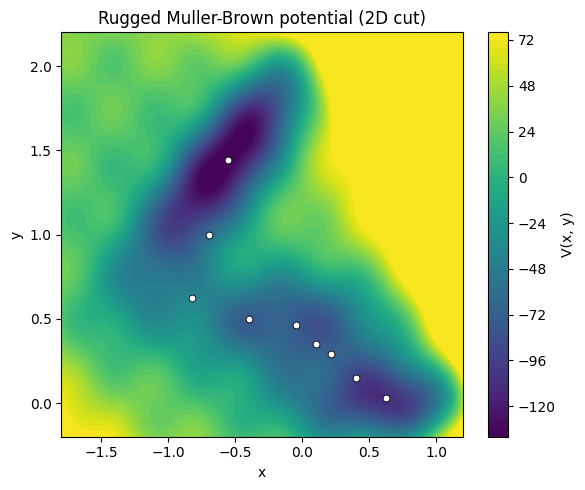

<Axes: title={'center': 'Rugged Muller-Brown potential (2D cut)'}, xlabel='x', ylabel='y'>

In [2]:
mep_nodes = [
    [-0.558,  1.442], # Minimum 1 (Haut gauche)
    [-0.700,  1.000], # Intermédiaire
    [-0.822,  0.624], # État de transition 1
    [-0.400,  0.500], # Intermédiaire
    [-0.050,  0.466], # Minimum 2 (Centre)
    [ 0.100,  0.350], # Intermédiaire
    [ 0.212,  0.293], # État de transition 2
    [ 0.400,  0.150], # Intermédiaire
    [ 0.623,  0.028]  # Minimum 3 (Bas droite)
]
calc.plot_2d_potential(clip_percentiles=[1,80], cmap='viridis', points= mep_nodes)

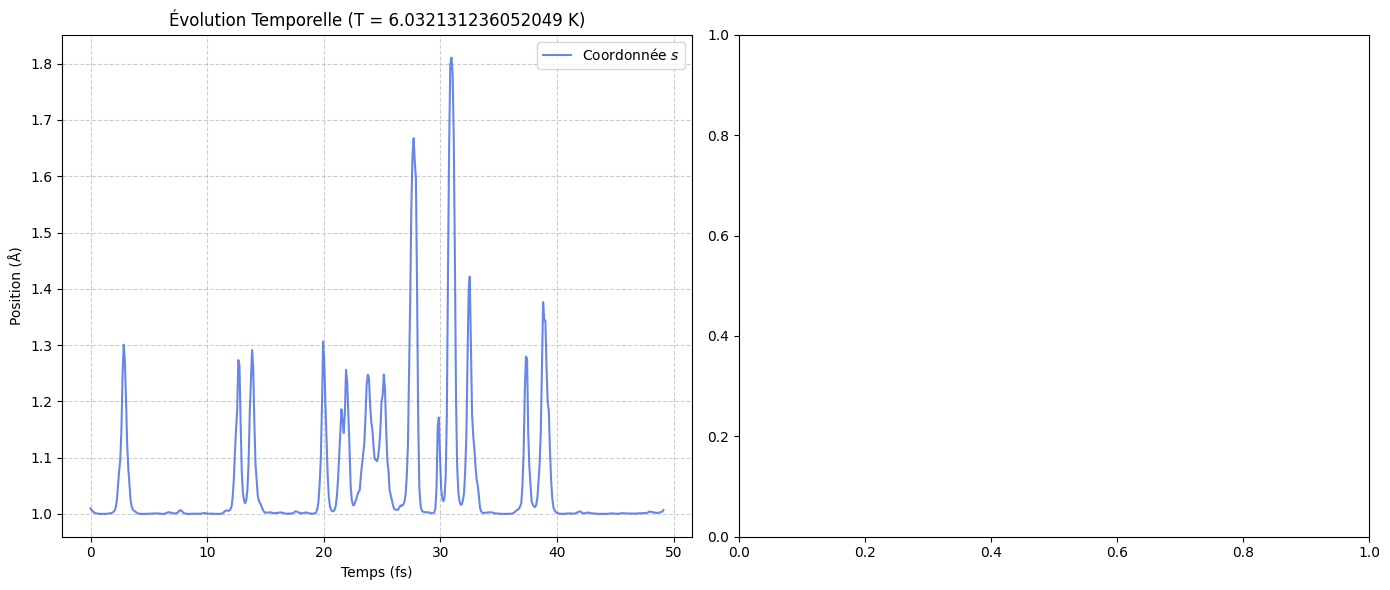

In [3]:
import matplotlib.pyplot as plt
from aseams.cvs import CollectiveVariables # En supposant que l'import vient de là
import numpy as np
from aseams.cvs import CollectiveVariables

class PathCollectiveVariable:
    """
    Calcule la position relative 's' le long d'un chemin défini par des nœuds.
    """
    def __init__(self, path_nodes, lambda_param):
        self.path_nodes = np.array(path_nodes)
        self.lambda_param = lambda_param
        self.N = len(path_nodes)
        # Les indices vont de 1 à N
        self.indices = np.arange(1, self.N + 1)

    def __call__(self, atoms):
        # On extrait uniquement (x, y) du premier atome (r_0, r_1)
        R = atoms.positions[0, :2]
        
        # Distances au carré ||R - R_i||^2
        dist_sq = np.sum((self.path_nodes - R)**2, axis=1)
        
        # Termes exponentiels
        exp_terms = np.exp(-self.lambda_param * dist_sq)
        sum_exp = np.sum(exp_terms)
        
        # Sécurité numérique : si on est extrêmement loin du chemin,
        # on renvoie l'indice du nœud le plus proche géométriquement.
        if sum_exp < 1e-50:
            return float(np.argmin(dist_sq) + 1)
            
        # Calcul de s(R)
        s = np.sum(self.indices * exp_terms) / sum_exp
        return float(s)

# ==========================================
# Initialisation pour le potentiel de Muller-Brown
# ==========================================

# Chemin de Moindre Énergie (MEP) approximatif pour le Muller-Brown classique.
# Les nœuds couvrent les 3 minima et les 2 états de transition.
# Pour une précision maximale, ces points devraient idéalement provenir
# d'une optimisation NEB (Nudged Elastic Band) ou d'un String Method.
mep_nodes = [
    [-0.558,  1.442], # Minimum 1 (Haut gauche)
    [-0.700,  1.000], # Intermédiaire
    [-0.822,  0.624], # État de transition 1
    [-0.400,  0.500], # Intermédiaire
    [-0.050,  0.466], # Minimum 2 (Centre)
    [ 0.100,  0.350], # Intermédiaire
    [ 0.212,  0.293], # État de transition 2
    [ 0.400,  0.150], # Intermédiaire
    [ 0.623,  0.028]  # Minimum 3 (Bas droite)
]

# Calcul du paramètre lambda : 
# La règle empirique standard est lambda ~ 2.3 / (distance_moyenne_entre_noeuds)^2
# Ici, les nœuds sont distants d'environ 0.3 à 0.4 Å.
mean_dist_sq = np.mean(np.sum(np.diff(mep_nodes, axis=0)**2, axis=1))
lambda_param = 2.3 / mean_dist_sq

# Instanciation de la fonction
s_path_cv = PathCollectiveVariable(path_nodes=mep_nodes, lambda_param=lambda_param)

# # Injection dans ton objet de variables collectives

# # -- 2. Suivi de la dynamique --
times = []
cv_values = []

def monitor_and_store():
    # Note : Pas de atoms.wrap() ici. Le potentiel de Muller-Brown 
    # n'est pas périodique, appliquer des conditions aux limites 
    # fausserait les positions absolues.
    
    cv_value = s_path_cv(atoms)
    times.append(dyn.get_number_of_steps() * dyn.dt)
    cv_values.append(cv_value)

# On attache la fonction à la dynamique (intervalle à ajuster selon le pas de temps)
dyn.attach(monitor_and_store, interval=1) 

# On lance la dynamique (ex: 5000 pas pour avoir le temps de voir une exploration)
dyn.run(500)

# -- 3. Visualisation --
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Graphique 1 : Évolution temporelle des coordonnées
ax1.plot(times, cv_values, label="Coordonnée $s$", color='royalblue', alpha=0.8)
ax1.set_xlabel("Temps (fs)")
ax1.set_ylabel("Position (Å)")
ax1.set_title(f"Évolution Temporelle (T = {dyn.temp} K)")
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [4]:

cv = CollectiveVariables(s_path_cv, s_path_cv, s_path_cv)  # On peut réutiliser la même fonction pour les trois composantes si on n'en a besoin que d'une

cv.set_r_crit("below")
R =1.
P = 9.0
cv.set_in_r_boundary(1.1)
cv.set_sigma_r_level(1.2)
cv.set_out_of_r_zone(2.0)

cv.set_p_crit("above")
cv.set_in_p_boundary(P-0.5)
# calc.plot_pes()
rng_ams, rng_ini, rng_dyn_ini, rng_dyn_ams = [np.random.default_rng(s) for s in [0, 0, 0, 0]]


In [5]:
import shutil


## Echantillonnage des conditions initiales
shutil.rmtree("./ini_conds_normal", ignore_errors=True)
sampler = SingleWalkerSampler(dyn,
                              cv,
                              cv_interval=1,
                              fixcm=False, rng = rng_ini)
sampler.set_run_dir("./ini_conds_normal", append_traj=False)
sampler.set_ini_cond_dir("./ini_conds_normal", clean=False)
n_rep = 100
print(f"Génération de {n_rep} conditions initiales brutes...")


sampler.sample(n_rep)

Génération de 100 conditions initiales brutes...


/work/moracchl/anaconda3/envs/girsams/lib/python3.14/site-packages/ase/io/extxyz.py:318: UserWarning: Skipping unhashable information noise
  warnings.warn('Skipping unhashable information '


In [6]:
## Calcul de la probabilité de transition via l'AMS

n_ams = 1
probas = []
seeds_ams = rng_ams.choice(10**6, size=10)
seeds_dyn = rng_dyn_ams.choice(10**6, size=10)
for k in range(n_ams):
    rng_ams = np.random.default_rng(seeds_ams[k])
    rng_dyn_ams = np.random.default_rng(seeds_dyn[k])
    
    dyn_ams = LangevinOBABO(atoms,
                       fixcm=False,
                       timestep=dt,
                       temperature_K=temperature_K,
                       friction=gamma,
                       logfile=None,
                       trajectory=None,
                       rng=rng_dyn_ams , record_noise=True)
    ams = AMS(n_rep=n_rep,
              k_min=1,
              dyn=dyn_ams,
              xi=cv,
              fixcm=False,
              save_all=False,
              rc_threshold=1e-6,
              verbose=False,
              rng=rng_ams)
    ams.set_ini_cond_dir("ini_conds_normal/")
    ams._reuse_ini_conds()
    ams.set_ams_dir("AMS_" + str(k) + "/", clean=True)
    def _wrap_pbc_positions():
        if np.any(ams.dyn.atoms.get_pbc()):
            ams.dyn.atoms.wrap()
    ams.dyn.attach(_wrap_pbc_positions, interval=1)
    ams._initialize()
    ams.run()
    probas.append(ams.p_ams())

res = np.array([np.mean(probas), np.std(probas, ddof=1) / np.sqrt(len(probas))])
print(res)
# np.savetxt('results.txt', res)

[2.56270715e-08            nan]


/work/moracchl/anaconda3/envs/girsams/lib/python3.14/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/work/moracchl/anaconda3/envs/girsams/lib/python3.14/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


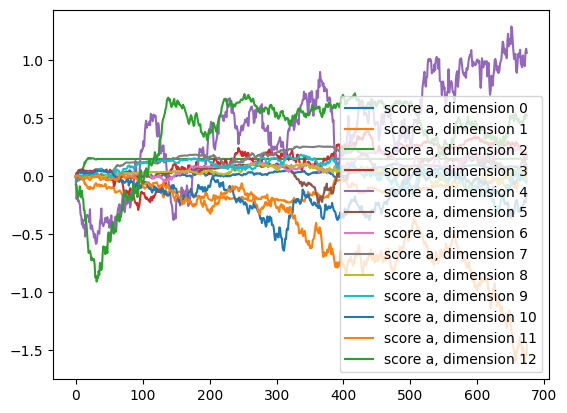

In [7]:
## Visualisation du score a de Girsanov sur une trajectoire finale.
masses = atoms.get_masses()
from ase.io import read
traj = read('./AMS_0/rep_1.traj', index=':')

cv_values = [s_path_cv(atoms) for atoms in traj]
reweightor = Reweightor(
    calculator=calc, 
    integrator="OBABO", 
    mode='linear', 
    temperature_K=temperature_K, 
    dt=dt, 
    friction=gamma, 
    masses=masses
)
score,fim = reweightor.reweight_one_trajectory_linear(traj,as_list = True)
import matplotlib.pyplot as plt
# plt.plot(cv_values, label = 'cv value')
for i in range(0, score.shape[1]):
    plt.plot(score[:, i], label =f"score a, dimension {i}")
plt.legend()